In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [3]:
df = pd.read_csv('sd254_users.csv')
df1 = pd.read_csv('sd254_cards.csv')
df2 = pd.read_csv('trans.csv')

In [4]:
df.head()

,Person,Current Age,Retirement Age,Birth Year,Birth Month,Gender,Address,Apartment,City,State,Zipcode,Latitude,Longitude,Per Capita Income - Zipcode,Yearly Income - Person,Total Debt,FICO Score,Num Credit Cards
0,Hazel Robinson,53,66,1966,11,Female,462 Rose Lane,NaN,La Verne,CA,91750,34.15,-117.76,$29278,$59696,$127613,787,5
1,Sasha Sadr,53,68,1966,12,Female,3606 Federal Boulevard,NaN,Little Neck,NY,11363,40.76,-73.74,$37891,$77254,$191349,701,5
2,Saanvi Lee,81,67,1938,11,Female,766 Third Drive,NaN,West Covina,CA,91792,34.02,-117.89,$22681,$33483,$196,698,5
3,Everlee Clark,63,63,1957,1,Female,3 Madison Street,NaN,New York,NY,10069,40.71,-73.99,$163145,$249925,$202328,722,4
4,Kyle Peterson,43,70,1976,9,Male,9620 Valley Stream Drive,NaN,San Francisco,CA,94117,37.76,-122.44,$53797,$109687,$183855,675,1


In [5]:
df1.head()

,User,CARD INDEX,Card Brand,Card Type,Card Number,Expires,CVV,Has Chip,Cards Issued,Credit Limit,Acct Open Date,Year PIN last Changed,Card on Dark Web
0,0,0,Visa,Debit,4344676511950444,12/2022,623,YES,2,$24295,09/2002,2008,No
1,0,1,Visa,Debit,4956965974959986,12/2020,393,YES,2,$21968,04/2014,2014,No
2,0,2,Visa,Debit,4582313478255491,02/2024,719,YES,2,$46414,07/2003,2004,No
3,0,3,Visa,Credit,4879494103069057,08/2024,693,NO,1,$12400,01/2003,2012,No
4,0,4,Mastercard,Debit (Prepaid),5722874738736011,03/2009,75,YES,1,$28,09/2008,2009,No


In [6]:
df2.head()

,User,Card,Year,Month,Day,Time,Amount,Use Chip,Merchant Name,Merchant City,Merchant State,Zip,MCC,Errors?,Is Fraud?
0,0,0,2002,9,1,06:21,$134.09,Swipe Transaction,3527213246127876953,La Verne,CA,91750.0,5300,NaN,No
1,0,0,2002,9,1,06:42,$38.48,Swipe Transaction,-727612092139916043,Monterey Park,CA,91754.0,5411,NaN,No
2,0,0,2002,9,2,06:22,$120.34,Swipe Transaction,-727612092139916043,Monterey Park,CA,91754.0,5411,NaN,No
3,0,0,2002,9,2,17:45,$128.95,Swipe Transaction,3414527459579106770,Monterey Park,CA,91754.0,5651,NaN,No
4,0,0,2002,9,3,06:23,$104.71,Swipe Transaction,5817218446178736267,La Verne,CA,91750.0,5912,NaN,No


# Users DataFrame

In [7]:
df['User'] = range(len(df))
print(df.head())

           Person  Current Age  Retirement Age  Birth Year  Birth Month  \
0  Hazel Robinson           53              66        1966           11   
1      Sasha Sadr           53              68        1966           12   
2      Saanvi Lee           81              67        1938           11   
3   Everlee Clark           63              63        1957            1   
4   Kyle Peterson           43              70        1976            9   

   Gender                   Address  Apartment           City State  Zipcode  \
0  Female             462 Rose Lane        NaN       La Verne    CA    91750   
1  Female    3606 Federal Boulevard        NaN    Little Neck    NY    11363   
2  Female           766 Third Drive        NaN    West Covina    CA    91792   
3  Female          3 Madison Street        NaN       New York    NY    10069   
4    Male  9620 Valley Stream Drive        NaN  San Francisco    CA    94117   

   Latitude  Longitude Per Capita Income - Zipcode Yearly Income - P

In [8]:
df.index

RangeIndex(start=0, stop=2000, step=1)

In [9]:
df.columns

Index(['Person', 'Current Age', 'Retirement Age', 'Birth Year', 'Birth Month',
       'Gender', 'Address', 'Apartment', 'City', 'State', 'Zipcode',
       'Latitude', 'Longitude', 'Per Capita Income - Zipcode',
       'Yearly Income - Person', 'Total Debt', 'FICO Score',
       'Num Credit Cards', 'User'],
      dtype='object')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Person                       2000 non-null   object 
 1   Current Age                  2000 non-null   int64  
 2   Retirement Age               2000 non-null   int64  
 3   Birth Year                   2000 non-null   int64  
 4   Birth Month                  2000 non-null   int64  
 5   Gender                       2000 non-null   object 
 6   Address                      2000 non-null   object 
 7   Apartment                    528 non-null    float64
 8   City                         2000 non-null   object 
 9   State                        2000 non-null   object 
 10  Zipcode                      2000 non-null   int64  
 11  Latitude                     2000 non-null   float64
 12  Longitude                    2000 non-null   float64
 13  Per Capita Income 

In [11]:
df.describe()

,Current Age,Retirement Age,Birth Year,Birth Month,Apartment,Zipcode,Latitude,Longitude,FICO Score,Num Credit Cards,User
count,2000.000000,2000.000000,2000.000000,2000.000000,528.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,45.391500,66.237500,1973.803000,6.439000,693.547348,50535.412000,37.389225,-91.554765,709.734500,3.073000,999.500000
std,18.414092,3.628867,18.421234,3.565338,1897.157861,29359.754742,5.114324,16.283293,67.221949,1.637379,577.494589
min,18.000000,50.000000,1918.000000,1.000000,1.000000,1060.000000,20.880000,-159.410000,480.000000,1.000000,0.000000
25%,30.000000,65.000000,1961.000000,3.000000,5.000000,28214.250000,33.837500,-97.395000,681.000000,2.000000,499.750000
50%,44.000000,66.000000,1975.000000,7.000000,10.000000,46305.500000,38.250000,-86.440000,711.500000,3.000000,999.500000
75%,58.000000,68.000000,1989.000000,10.000000,95.250000,77086.250000,41.200000,-80.130000,753.000000,4.000000,1499.250000
max,101.000000,79.000000,2002.000000,12.000000,9940.000000,99508.000000,61.200000,-68.670000,850.000000,9.000000,1999.000000


In [12]:
df.describe(include='object')

,Person,Gender,Address,City,State,Per Capita Income - Zipcode,Yearly Income - Person,Total Debt
count,2000,2000,2000,2000,2000,2000,2000,2000
unique,1993,2,1999,1286,51,1754,1948,1880
top,Hazel Robinson,Female,506 Washington Lane,Houston,CA,$0,$44128,$0
freq,2,1016,2,22,244,15,3,102


In [13]:
df.isnull().sum()

Person                            0
Current Age                       0
Retirement Age                    0
Birth Year                        0
Birth Month                       0
Gender                            0
Address                           0
Apartment                      1472
City                              0
State                             0
Zipcode                           0
Latitude                          0
Longitude                         0
Per Capita Income - Zipcode       0
Yearly Income - Person            0
Total Debt                        0
FICO Score                        0
Num Credit Cards                  0
User                              0
dtype: int64

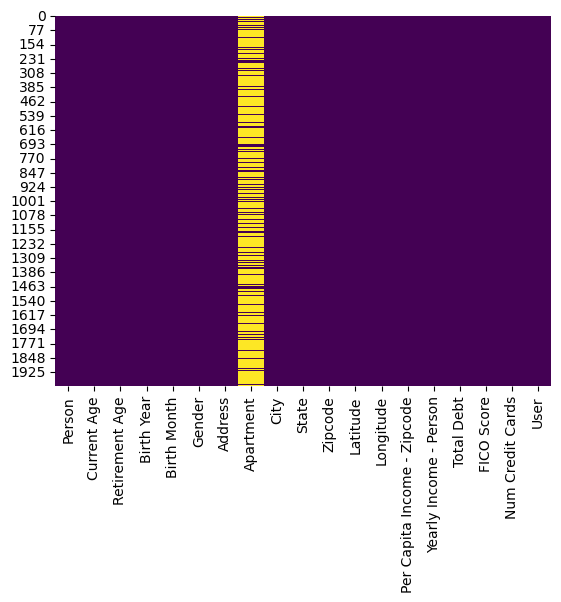

In [14]:
sns.heatmap(df.isnull(),cbar = False , cmap = 'viridis' )
plt.show()

In [15]:
df = df.drop(['Address', 'Apartment', 'Zipcode', 'Latitude', 'Zipcode'] , axis = 1)

In [16]:
df = df.drop('Longitude' , axis = 1)

In [17]:
df.head()

,Person,Current Age,Retirement Age,Birth Year,Birth Month,Gender,City,State,Per Capita Income - Zipcode,Yearly Income - Person,Total Debt,FICO Score,Num Credit Cards,User
0,Hazel Robinson,53,66,1966,11,Female,La Verne,CA,$29278,$59696,$127613,787,5,0
1,Sasha Sadr,53,68,1966,12,Female,Little Neck,NY,$37891,$77254,$191349,701,5,1
2,Saanvi Lee,81,67,1938,11,Female,West Covina,CA,$22681,$33483,$196,698,5,2
3,Everlee Clark,63,63,1957,1,Female,New York,NY,$163145,$249925,$202328,722,4,3
4,Kyle Peterson,43,70,1976,9,Male,San Francisco,CA,$53797,$109687,$183855,675,1,4


# Cards Data 

In [18]:
df1.head()

,User,CARD INDEX,Card Brand,Card Type,Card Number,Expires,CVV,Has Chip,Cards Issued,Credit Limit,Acct Open Date,Year PIN last Changed,Card on Dark Web
0,0,0,Visa,Debit,4344676511950444,12/2022,623,YES,2,$24295,09/2002,2008,No
1,0,1,Visa,Debit,4956965974959986,12/2020,393,YES,2,$21968,04/2014,2014,No
2,0,2,Visa,Debit,4582313478255491,02/2024,719,YES,2,$46414,07/2003,2004,No
3,0,3,Visa,Credit,4879494103069057,08/2024,693,NO,1,$12400,01/2003,2012,No
4,0,4,Mastercard,Debit (Prepaid),5722874738736011,03/2009,75,YES,1,$28,09/2008,2009,No


In [19]:
df1.isnull().sum()

User                     0
CARD INDEX               0
Card Brand               0
Card Type                0
Card Number              0
Expires                  0
CVV                      0
Has Chip                 0
Cards Issued             0
Credit Limit             0
Acct Open Date           0
Year PIN last Changed    0
Card on Dark Web         0
dtype: int64

In [20]:
df1.index

RangeIndex(start=0, stop=6146, step=1)

In [21]:
df1.columns

Index(['User', 'CARD INDEX', 'Card Brand', 'Card Type', 'Card Number',
       'Expires', 'CVV', 'Has Chip', 'Cards Issued', 'Credit Limit',
       'Acct Open Date', 'Year PIN last Changed', 'Card on Dark Web'],
      dtype='object')

In [22]:
df1.describe()

,User,CARD INDEX,Card Number,CVV,Cards Issued,Year PIN last Changed
count,6146.000000,6146.000000,6.146000e+03,6146.000000,6146.000000,6146.000000
mean,1003.477058,1.472502,4.820426e+15,506.220794,1.503091,2013.436707
std,571.724745,1.463294,1.328582e+15,289.431123,0.519191,4.270699
min,0.000000,0.000000,3.001055e+14,0.000000,1.000000,2002.000000
25%,508.250000,0.000000,4.486365e+15,257.000000,1.000000,2010.000000
50%,1004.000000,1.000000,5.108957e+15,516.500000,1.000000,2013.000000
75%,1493.750000,2.000000,5.585237e+15,756.000000,2.000000,2017.000000
max,1999.000000,8.000000,6.997197e+15,999.000000,3.000000,2020.000000


In [23]:
df1.describe(include = 'object') 

,Card Brand,Card Type,Expires,Has Chip,Credit Limit,Acct Open Date,Card on Dark Web
count,6146,6146,6146,6146,6146,6146,6146
unique,4,3,259,2,3654,303,1
top,Mastercard,Debit,02/2020,YES,$0,02/2020,No
freq,3209,3511,377,5500,31,607,6146


# Merge Data

In [24]:
df3 = pd.merge(df , df1 , how = 'inner' , on = 'User')

In [25]:
df3.head(100)

,Person,Current Age,Retirement Age,Birth Year,Birth Month,Gender,City,State,Per Capita Income - Zipcode,Yearly Income - Person,...,Card Type,Card Number,Expires,CVV,Has Chip,Cards Issued,Credit Limit,Acct Open Date,Year PIN last Changed,Card on Dark Web
0,Hazel Robinson,53,66,1966,11,Female,La Verne,CA,$29278,$59696,...,Debit,4344676511950444,12/2022,623,YES,2,$24295,09/2002,2008,No
1,Hazel Robinson,53,66,1966,11,Female,La Verne,CA,$29278,$59696,...,Debit,4956965974959986,12/2020,393,YES,2,$21968,04/2014,2014,No
2,Hazel Robinson,53,66,1966,11,Female,La Verne,CA,$29278,$59696,...,Debit,4582313478255491,02/2024,719,YES,2,$46414,07/2003,2004,No
3,Hazel Robinson,53,66,1966,11,Female,La Verne,CA,$29278,$59696,...,Credit,4879494103069057,08/2024,693,NO,1,$12400,01/2003,2012,No
4,Hazel Robinson,53,66,1966,11,Female,La Verne,CA,$29278,$59696,...,Debit (Prepaid),5722874738736011,03/2009,75,YES,1,$28,09/2008,2009,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,Rosa Faraday,21,66,1998,9,Female,Old Saybrook,CT,$30281,$61746,...,Debit,5068255294282305,11/2020,890,YES,1,$25815,12/2017,2017,No
96,Brynn Allen,47,65,1972,11,Female,Mobile,AL,$21331,$43496,...,Credit,354813103334804,06/2021,527,YES,2,$8400,01/2014,2014,No
97,Brynn Allen,47,65,1972,11,Female,Mobile,AL,$21331,$43496,...,Debit,5910929635230868,02/2020,525,YES,1,$21628,03/2001,2008,No
98,Brynn Allen,47,65,1972,11,Female,Mobile,AL,$21331,$43496,...,Debit,5400182448188961,10/2021,412,YES,1,$24232,07/2009,2009,No


In [26]:
df3.isnull().sum()

Person                         0
Current Age                    0
Retirement Age                 0
Birth Year                     0
Birth Month                    0
Gender                         0
City                           0
State                          0
Per Capita Income - Zipcode    0
Yearly Income - Person         0
Total Debt                     0
FICO Score                     0
Num Credit Cards               0
User                           0
CARD INDEX                     0
Card Brand                     0
Card Type                      0
Card Number                    0
Expires                        0
CVV                            0
Has Chip                       0
Cards Issued                   0
Credit Limit                   0
Acct Open Date                 0
Year PIN last Changed          0
Card on Dark Web               0
dtype: int64

In [27]:
df3.describe(include = 'object')

,Person,Gender,City,State,Per Capita Income - Zipcode,Yearly Income - Person,Total Debt,Card Brand,Card Type,Expires,Has Chip,Credit Limit,Acct Open Date,Card on Dark Web
count,6146,6146,6146,6146,6146,6146,6146,6146,6146,6146,6146,6146,6146,6146
unique,1993,2,1286,51,1754,1948,1880,4,3,259,2,3654,303,1
top,Casey El-Mafouk,Female,Houston,CA,$0,$48750,$0,Mastercard,Debit,02/2020,YES,$0,02/2020,No
freq,10,3139,69,774,41,13,365,3209,3511,377,5500,31,607,6146


In [28]:
df3.columns

Index(['Person', 'Current Age', 'Retirement Age', 'Birth Year', 'Birth Month',
       'Gender', 'City', 'State', 'Per Capita Income - Zipcode',
       'Yearly Income - Person', 'Total Debt', 'FICO Score',
       'Num Credit Cards', 'User', 'CARD INDEX', 'Card Brand', 'Card Type',
       'Card Number', 'Expires', 'CVV', 'Has Chip', 'Cards Issued',
       'Credit Limit', 'Acct Open Date', 'Year PIN last Changed',
       'Card on Dark Web'],
      dtype='object')

In [29]:
df3.head(20)

,Person,Current Age,Retirement Age,Birth Year,Birth Month,Gender,City,State,Per Capita Income - Zipcode,Yearly Income - Person,...,Card Type,Card Number,Expires,CVV,Has Chip,Cards Issued,Credit Limit,Acct Open Date,Year PIN last Changed,Card on Dark Web
0,Hazel Robinson,53,66,1966,11,Female,La Verne,CA,$29278,$59696,...,Debit,4344676511950444,12/2022,623,YES,2,$24295,09/2002,2008,No
1,Hazel Robinson,53,66,1966,11,Female,La Verne,CA,$29278,$59696,...,Debit,4956965974959986,12/2020,393,YES,2,$21968,04/2014,2014,No
2,Hazel Robinson,53,66,1966,11,Female,La Verne,CA,$29278,$59696,...,Debit,4582313478255491,02/2024,719,YES,2,$46414,07/2003,2004,No
3,Hazel Robinson,53,66,1966,11,Female,La Verne,CA,$29278,$59696,...,Credit,4879494103069057,08/2024,693,NO,1,$12400,01/2003,2012,No
4,Hazel Robinson,53,66,1966,11,Female,La Verne,CA,$29278,$59696,...,Debit (Prepaid),5722874738736011,03/2009,75,YES,1,$28,09/2008,2009,No
5,Sasha Sadr,53,68,1966,12,Female,Little Neck,NY,$37891,$77254,...,Credit,4404898874682993,09/2003,736,YES,1,$27500,09/2003,2012,No
6,Sasha Sadr,53,68,1966,12,Female,Little Neck,NY,$37891,$77254,...,Debit,4001482973848631,07/2022,972,YES,2,$28508,02/2011,2011,No
7,Sasha Sadr,53,68,1966,12,Female,Little Neck,NY,$37891,$77254,...,Debit,5627220683410948,06/2022,48,YES,2,$9022,07/2003,2015,No
8,Sasha Sadr,53,68,1966,12,Female,Little Neck,NY,$37891,$77254,...,Debit (Prepaid),5711382187309326,11/2020,722,YES,2,$54,06/2010,2015,No
9,Sasha Sadr,53,68,1966,12,Female,Little Neck,NY,$37891,$77254,...,Debit (Prepaid),5766121508358701,02/2023,908,YES,1,$99,07/2006,2012,No


# EDA

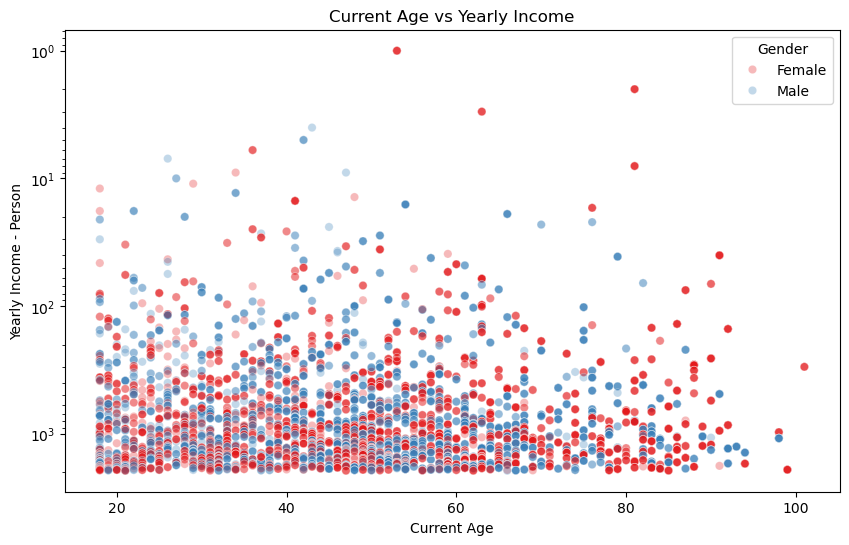

In [30]:
plt.figure(figsize = (10 ,6))
sns.scatterplot(data = df3 , x='Current Age',y = 'Yearly Income - Person' , alpha = 0.3 , hue = 'Gender' , palette = 'Set1')
plt.yscale('log')
plt.title('Current Age vs Yearly Income')
plt.show()

In [31]:
# First, check if the columns exist in your dataframe
columns_to_clean = ['Yearly Income - Person', 'Per Capita Income - Zipcode', 'Credit Limit']

# Make sure all columns exist in df3
existing_columns = [col for col in columns_to_clean if col in df3.columns]

# Clean only the existing columns
for col in existing_columns:
    df3[col] = df3[col].replace('[\$,]', '', regex=True).astype(float)

# Display the cleaned columns from df3 (not df)
df3[existing_columns].head()

# Alternatively, if you meant to use df instead of df3 for display:
# df3[existing_columns].head()





,Yearly Income - Person,Per Capita Income - Zipcode,Credit Limit
0,59696.0,29278.0,24295.0
1,59696.0,29278.0,21968.0
2,59696.0,29278.0,46414.0
3,59696.0,29278.0,12400.0
4,59696.0,29278.0,28.0


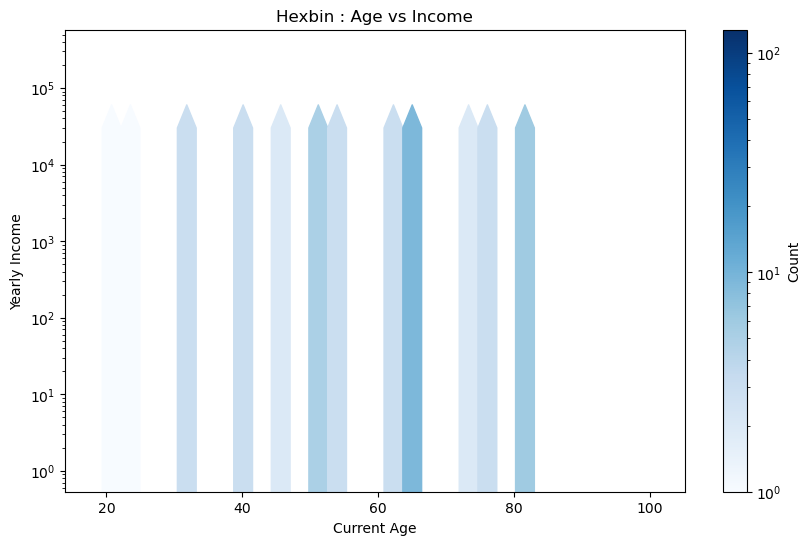

In [32]:
plt.figure(figsize = (10,6))
plt.hexbin(x = df3['Current Age'] , y = df3['Yearly Income - Person'], gridsize = 30 , cmap = 'Blues' , bins = 'log')
plt.colorbar(label = 'Count')
plt.yscale('log')
plt.xlabel('Current Age')
plt.ylabel('Yearly Income')
plt.title('Hexbin : Age vs Income')
plt.show()


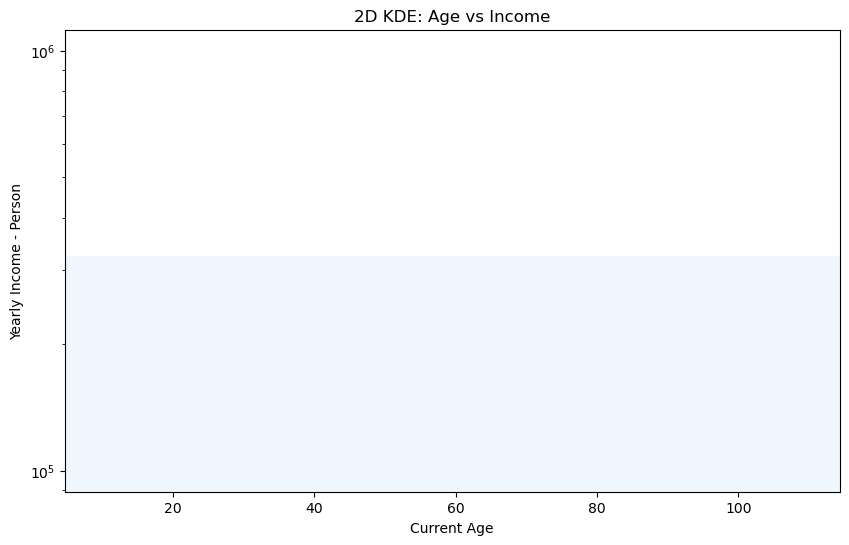

In [33]:
plt.figure(figsize=(10,6))
sns.kdeplot(
    data=df3,
    x='Current Age',
    y='Yearly Income - Person',
    fill=True,
    cmap='Blues',
    thresh=0
)
plt.yscale('log')
plt.title('2D KDE: Age vs Income')
plt.show()

/var/folders/s4/m8r6vx7j7873dljxvwf3ts9r0000gn/T/ipykernel_55295/2214720891.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


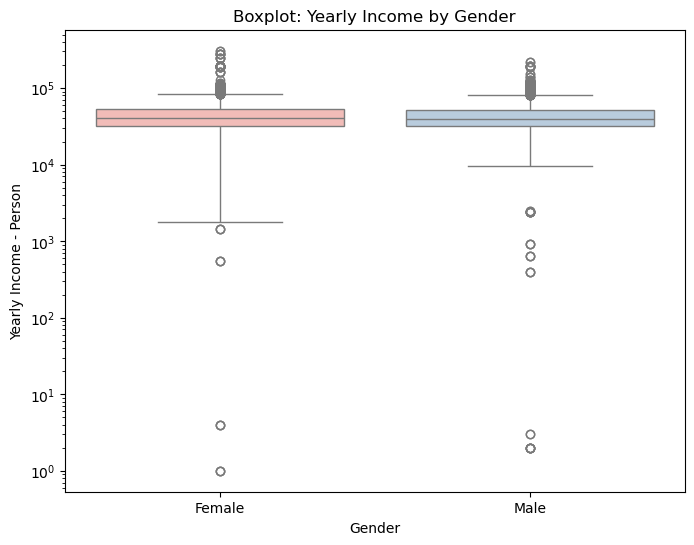

In [34]:
plt.figure(figsize=(8,6))
sns.boxplot(
    data=df3,
    x='Gender',
    y='Yearly Income - Person',
    palette='Pastel1'
)
plt.yscale('log')
plt.title('Boxplot: Yearly Income by Gender')
plt.show()

/var/folders/s4/m8r6vx7j7873dljxvwf3ts9r0000gn/T/ipykernel_55295/1043592900.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


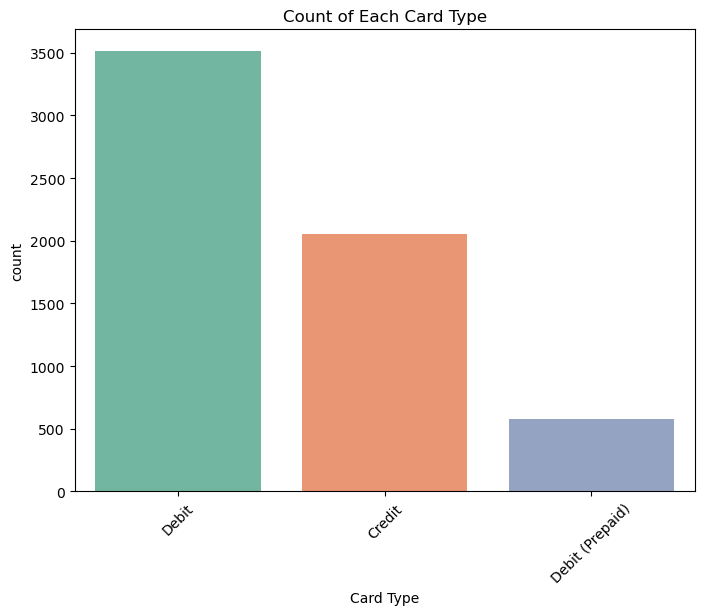

In [35]:
plt.figure(figsize=(8,6))
sns.countplot(
    data=df3,
    x='Card Type',
    order=df3['Card Type'].value_counts().index,
    palette='Set2'
)
plt.xticks(rotation=45)
plt.title('Count of Each Card Type')
plt.show()

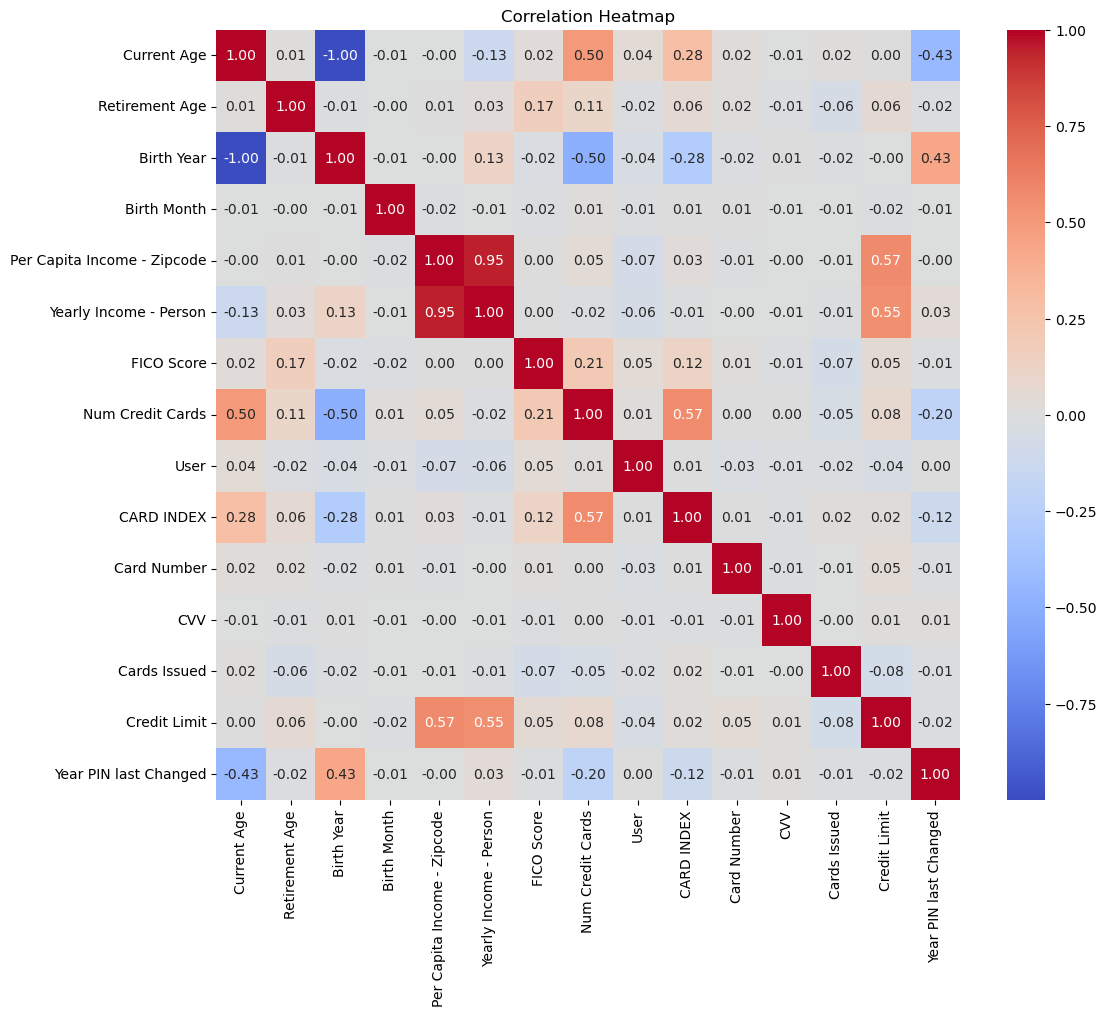

In [36]:
plt.figure(figsize=(12,10))
sns.heatmap(
    df3.select_dtypes(include='number').corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)
plt.title('Correlation Heatmap')
plt.show()



In [37]:
df3.to_csv('User_Card.csv',index = False)
print("DataFrame saved as cleaned_financial_data")

DataFrame saved as cleaned_financial_data
